# VS1 振动传感器 — 数据分析
Hydraulic Systems Dataset | 1 Hz 采样 | 2205 周期 × 60 秒/周期

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft, signal, stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = r"C:\Users\Lenovo\Desktop\项目集合\Hydraulic Systems dataset"


In [2]:
# 加载 VS1 和标签文件
vs1 = pd.read_csv(os.path.join(DATA_DIR, "VS1.txt"), sep="\t", header=None)
profile = pd.read_csv(os.path.join(DATA_DIR, "profile.txt"), sep="\t", header=None)
profile.columns = ["Cooler", "Valve", "Pump_Leakage", "Accumulator", "Stable"]

print(f"VS1 形状: {vs1.shape} — {vs1.shape[0]} 个周期, {vs1.shape[1]} 个时间点/周期")
print(f"Profile 形状: {profile.shape}")
print(f"\n标签值域:\n{profile.describe().round(1)}")


VS1 形状: (2205, 60) — 2205 个周期, 60 个时间点/周期
Profile 形状: (2205, 5)

标签值域:
       Cooler   Valve  Pump_Leakage  Accumulator  Stable
count  2205.0  2205.0        2205.0       2205.0  2205.0
mean     41.2    90.7           0.7        107.2     0.3
std      42.4    10.7           0.8         16.4     0.5
min       3.0    73.0           0.0         90.0     0.0
25%       3.0    80.0           0.0         90.0     0.0
50%      20.0   100.0           0.0        100.0     0.0
75%     100.0   100.0           1.0        130.0     1.0
max     100.0   100.0           2.0        130.0     1.0


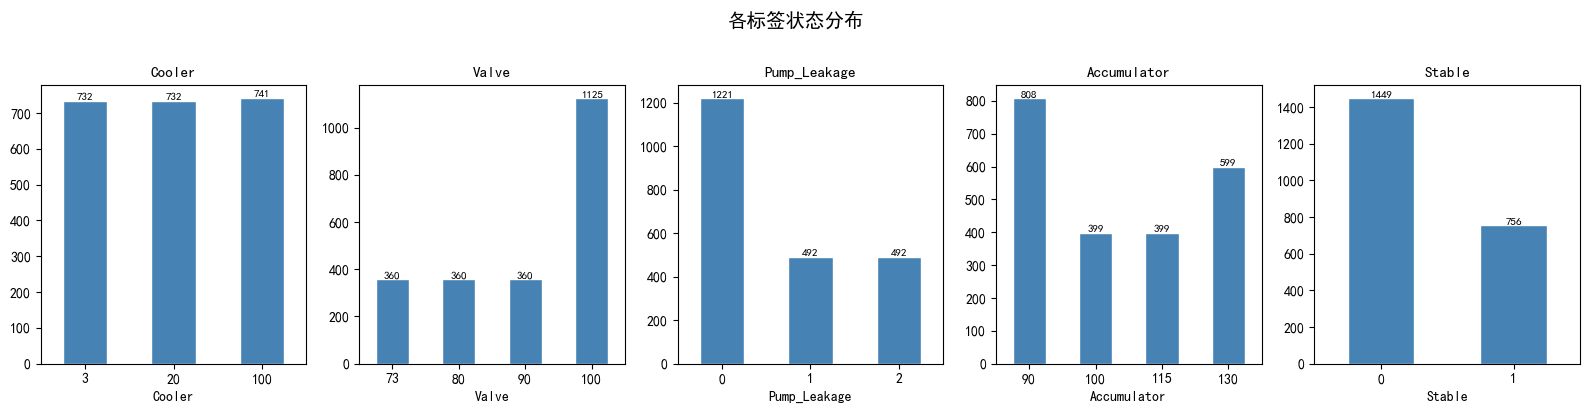

In [3]:
# 各故障状态的值计数
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, profile.columns):
    profile[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, int(bar.get_height()), ha="center", fontsize=8)
plt.suptitle("各标签状态分布", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 1. 单周期振动波形

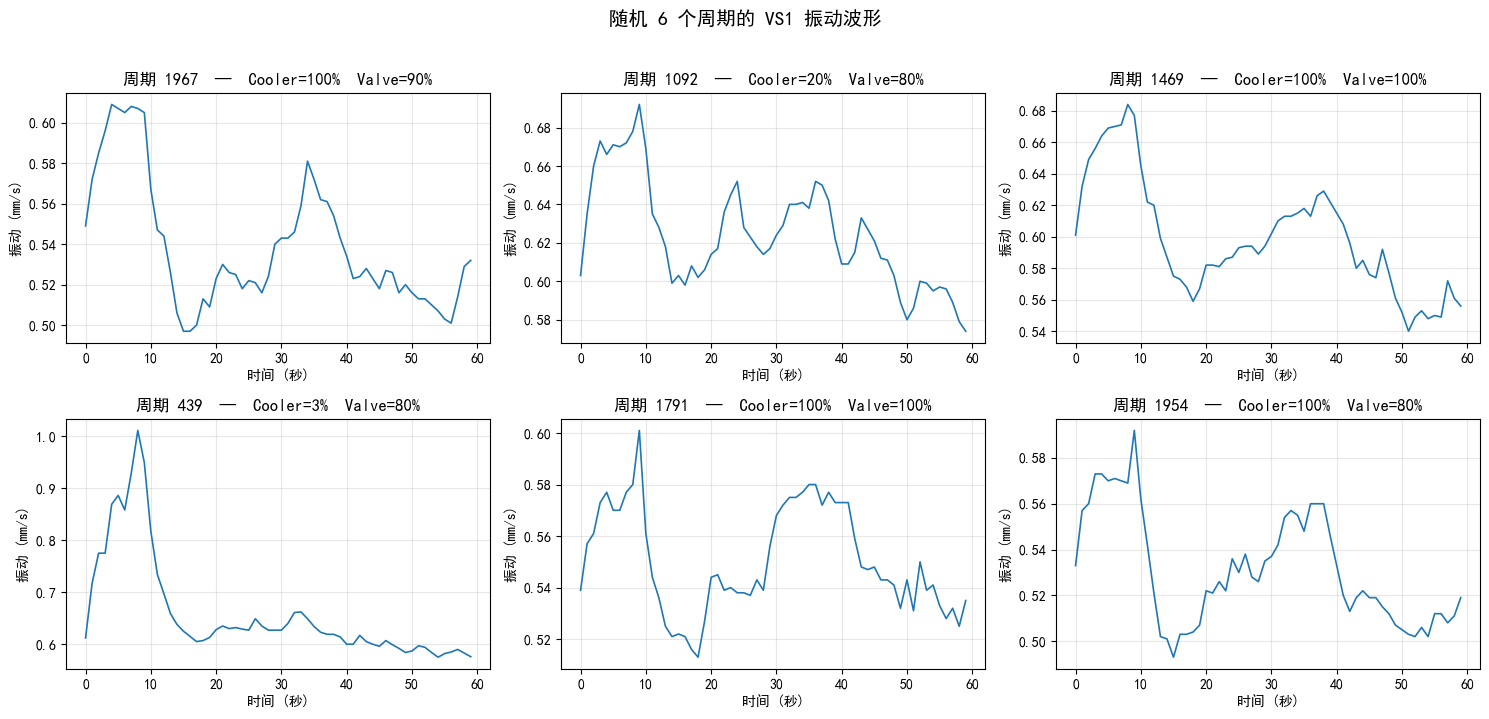

In [4]:
# 随机画 6 个周期的振动曲线
np.random.seed(42)
sample_ids = np.random.choice(vs1.shape[0], 6, replace=False)
time = np.arange(0, 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, idx in zip(axes.flat, sample_ids):
    ax.plot(time, vs1.iloc[idx, :], linewidth=1.2)
    ax.set_title(f"周期 {idx+1}  —  Cooler={profile.loc[idx,'Cooler']:.0f}%  Valve={profile.loc[idx,'Valve']:.0f}%")
    ax.set_xlabel("时间 (秒)")
    ax.set_ylabel("振动 (mm/s)")
    ax.grid(True, alpha=0.3)
plt.suptitle("随机 6 个周期的 VS1 振动波形", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 2. 按故障类型对比 — 振动跟故障有关吗？

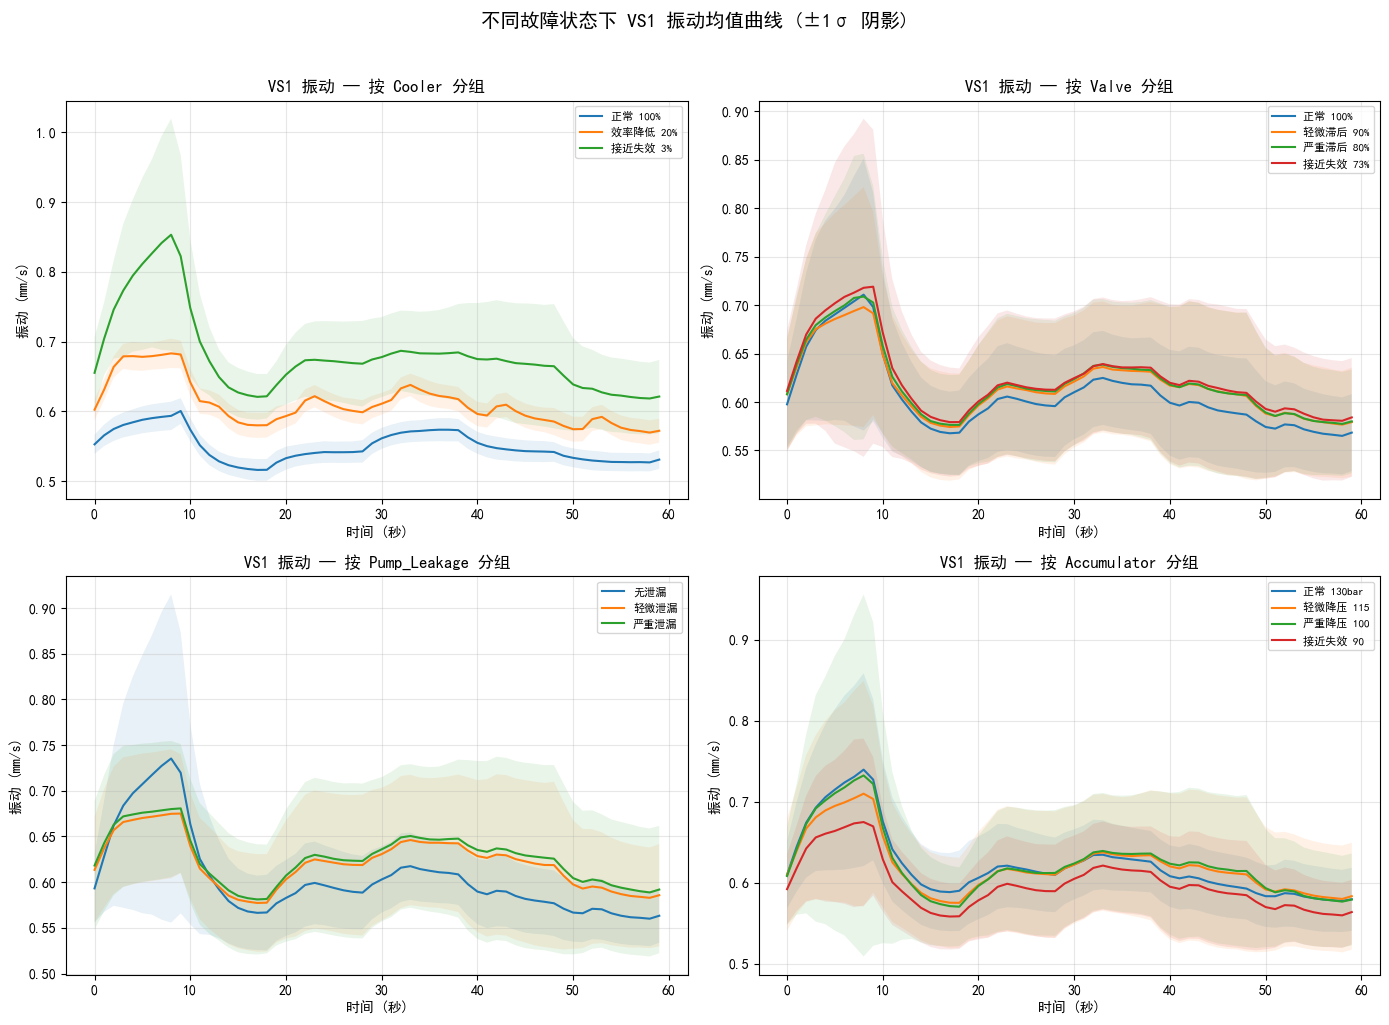

In [5]:
# 针对每个故障标签，画出正常 vs 故障的振动均值曲线
fault_config = [
    ("Cooler", {100: "正常 100%", 20: "效率降低 20%", 3: "接近失效 3%"}),
    ("Valve", {100: "正常 100%", 90: "轻微滞后 90%", 80: "严重滞后 80%", 73: "接近失效 73%"}),
    ("Pump_Leakage", {0: "无泄漏", 1: "轻微泄漏", 2: "严重泄漏"}),
    ("Accumulator", {130: "正常 130bar", 115: "轻微降压 115", 100: "严重降压 100", 90: "接近失效 90"}),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
time = np.arange(0, 60)

for ax, (col, labels) in zip(axes.flat, fault_config):
    for val, name in labels.items():
        mask = profile[col] == val
        if mask.sum() > 0:
            mean_curve = vs1[mask].mean(axis=0)
            std_curve  = vs1[mask].std(axis=0)
            ax.plot(time, mean_curve, label=name, linewidth=1.5)
            ax.fill_between(time, mean_curve - std_curve, mean_curve + std_curve, alpha=0.1)
    ax.set_title(f"VS1 振动 — 按 {col} 分组")
    ax.set_xlabel("时间 (秒)")
    ax.set_ylabel("振动 (mm/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("不同故障状态下 VS1 振动均值曲线 (±1σ 阴影)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 3. 周期级别的统计量分布

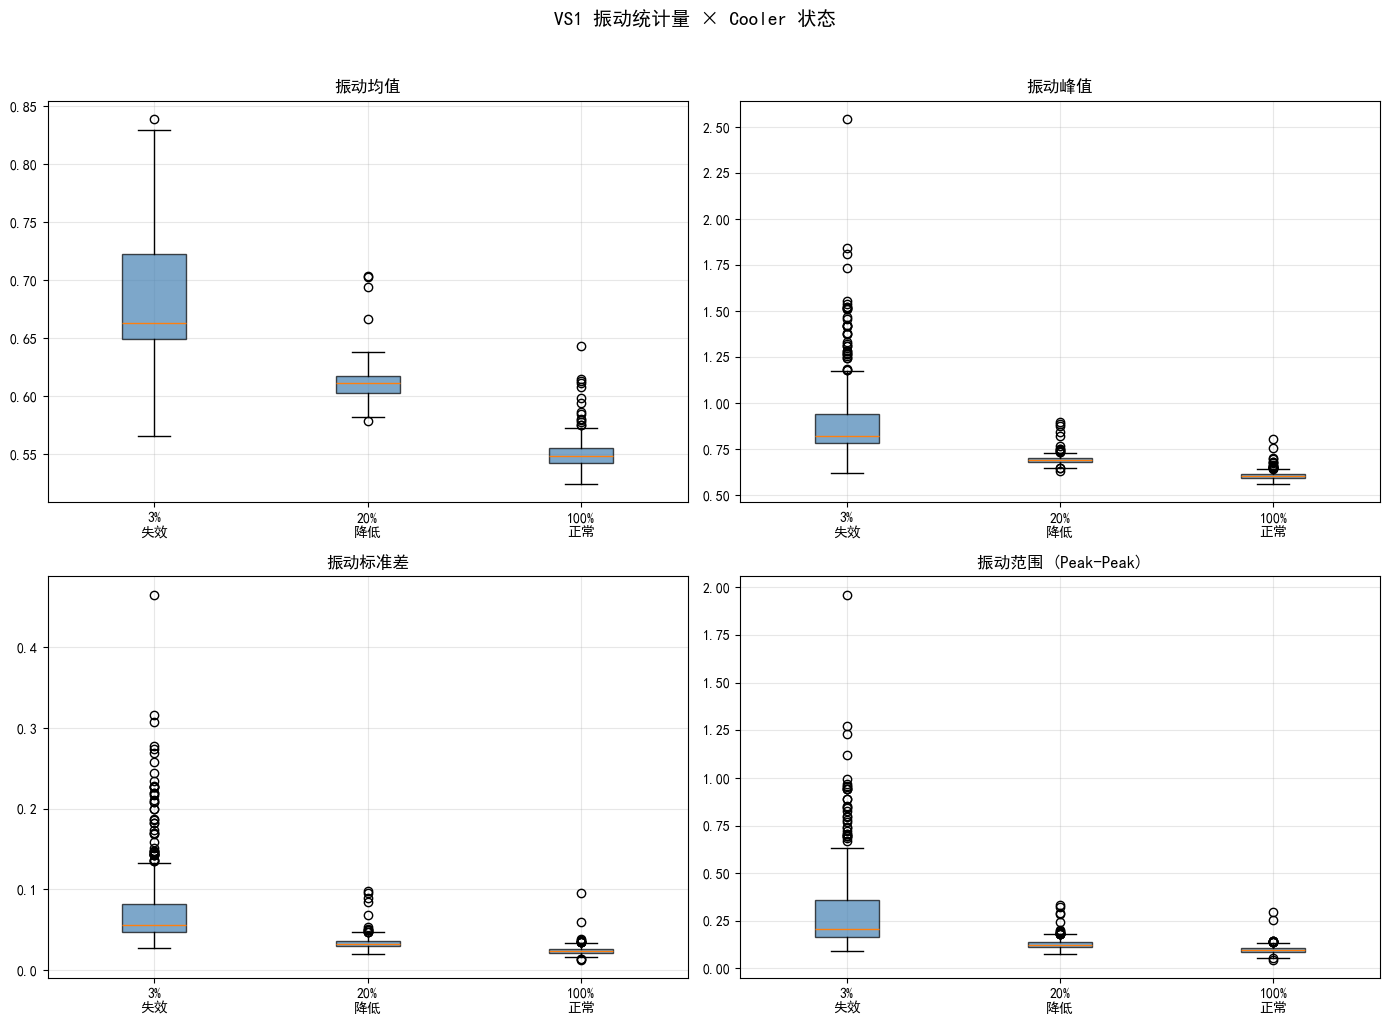

In [6]:
# 每个周期计算均值、峰值、标准差
vs1_stats = pd.DataFrame({
    "mean": vs1.mean(axis=1),
    "peak": vs1.max(axis=1),
    "std": vs1.std(axis=1),
    "range": vs1.max(axis=1) - vs1.min(axis=1),
    "Cooler": profile["Cooler"],
    "Valve": profile["Valve"],
    "Pump_Leakage": profile["Pump_Leakage"],
    "Accumulator": profile["Accumulator"],
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
stat_names = ["mean", "peak", "std", "range"]
titles = ["振动均值", "振动峰值", "振动标准差", "振动范围 (Peak-Peak)"]

for ax, stat, title in zip(axes.flat, stat_names, titles):
    data_by_cooler = [vs1_stats[vs1_stats["Cooler"] == v][stat].values
                      for v in sorted(vs1_stats["Cooler"].unique())]
    bp = ax.boxplot(data_by_cooler, tick_labels=["3%\n失效", "20%\n降低", "100%\n正常"], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.suptitle("VS1 振动统计量 × Cooler 状态", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. 频域分析 (FFT) — 振动信号的频谱差异

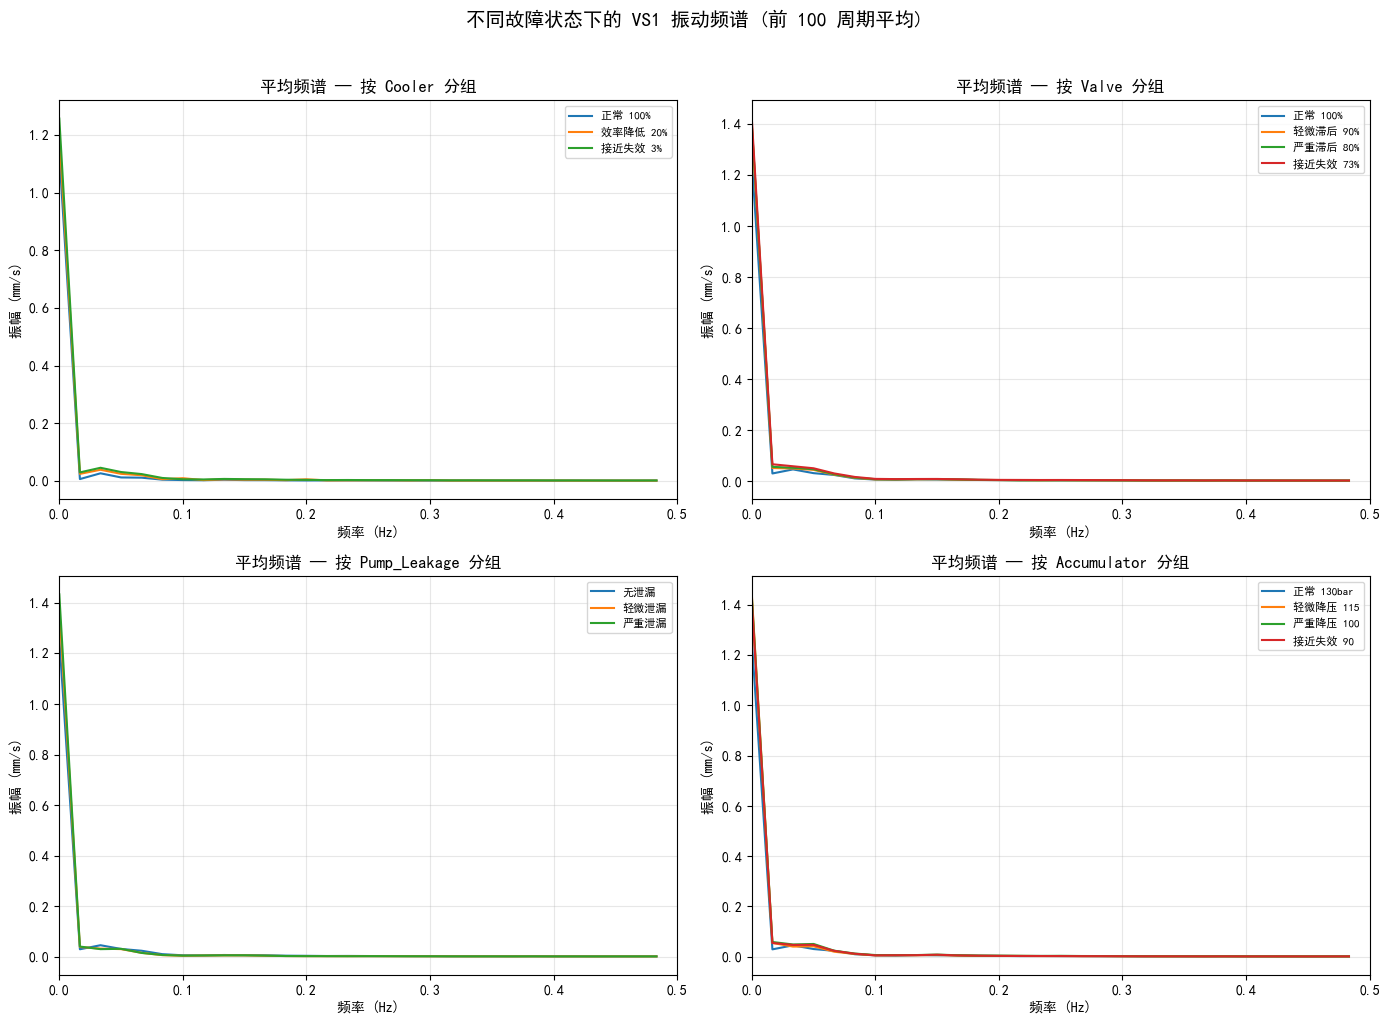

In [7]:
# 计算单边振幅谱
def compute_fft(signal_1d, fs=1.0):
    n = len(signal_1d)
    yf = fft.fft(signal_1d.values)
    xf = fft.fftfreq(n, d=1/fs)
    half_n = n // 2
    return xf[:half_n], np.abs(yf[:half_n]) / n * 2

# 每种故障状态各取 100 个周期的平均频谱
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, labels) in zip(axes.flat, fault_config):
    for val, name in labels.items():
        mask = profile[col] == val
        if mask.sum() > 0:
            samples = vs1[mask].iloc[:100]
            spectra = []
            for i in range(len(samples)):
                xf, amp = compute_fft(samples.iloc[i])
                spectra.append(amp)
            mean_spectrum = np.mean(spectra, axis=0)
            ax.plot(xf, mean_spectrum, label=name, linewidth=1.5)
    ax.set_title(f"平均频谱 — 按 {col} 分组")
    ax.set_xlabel("频率 (Hz)")
    ax.set_ylabel("振幅 (mm/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 0.5)
plt.suptitle("不同故障状态下的 VS1 振动频谱 (前 100 周期平均)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


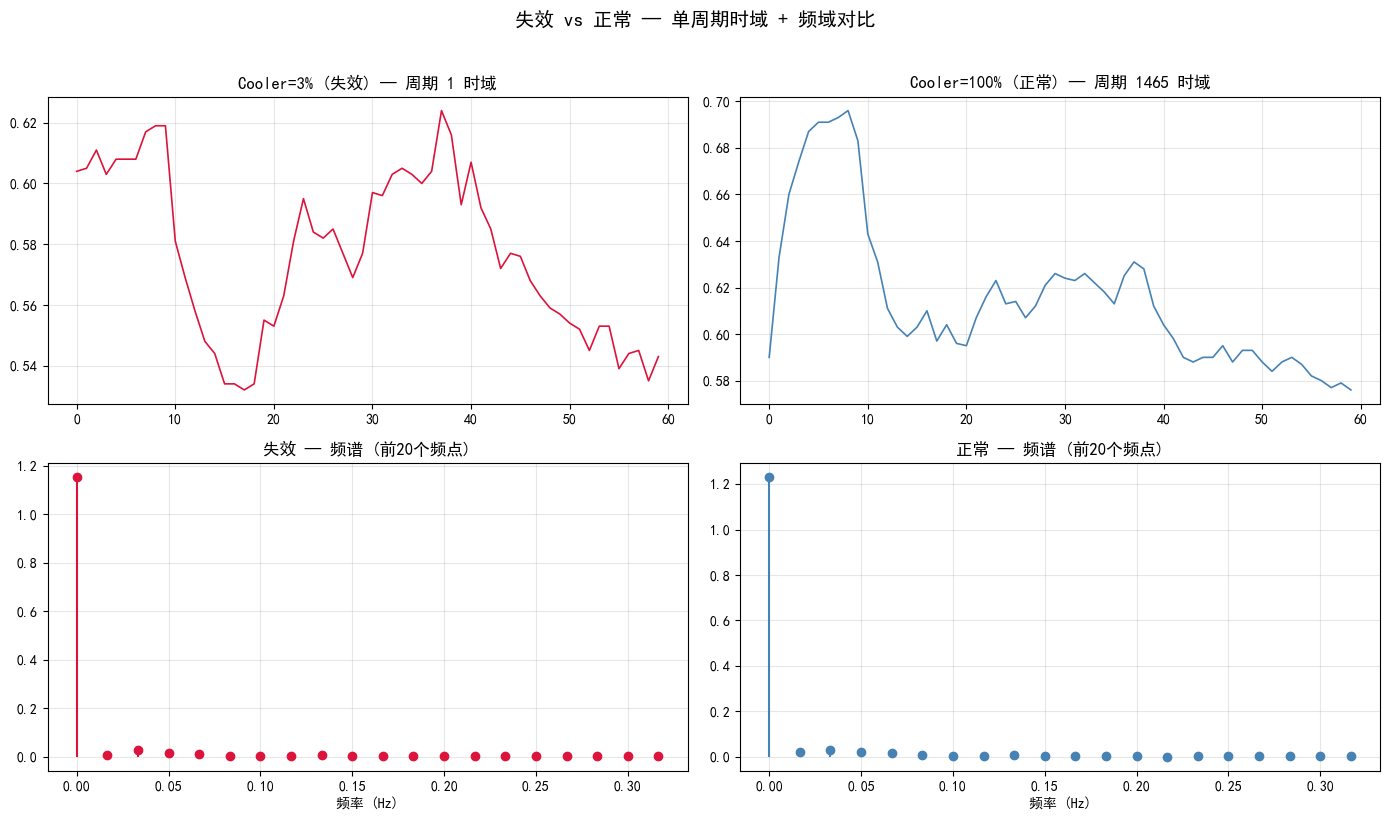

In [8]:
# 取 Cooler 失效 vs 正常各一个周期，对比时域和频域
idx_fail   = profile[profile["Cooler"] == 3].index[0]
idx_normal = profile[profile["Cooler"] == 100].index[0]

xf, spec_fail   = compute_fft(vs1.iloc[idx_fail])
_,  spec_normal = compute_fft(vs1.iloc[idx_normal])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# 时域
axes[0,0].plot(vs1.iloc[idx_fail].values,   linewidth=1.2, color="crimson")
axes[0,0].set_title(f"Cooler=3% (失效) — 周期 {idx_fail+1} 时域")
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(vs1.iloc[idx_normal].values, linewidth=1.2, color="steelblue")
axes[0,1].set_title(f"Cooler=100% (正常) — 周期 {idx_normal+1} 时域")
axes[0,1].grid(True, alpha=0.3)
# 频域
axes[1,0].stem(xf[:20], spec_fail[:20], linefmt='crimson', markerfmt='o', basefmt=' ')
axes[1,0].set_title("失效 — 频谱 (前20个频点)")
axes[1,0].set_xlabel("频率 (Hz)")
axes[1,0].grid(True, alpha=0.3)
axes[1,1].stem(xf[:20], spec_normal[:20], linefmt='steelblue', markerfmt='o', basefmt=' ')
axes[1,1].set_title("正常 — 频谱 (前20个频点)")
axes[1,1].set_xlabel("频率 (Hz)")
axes[1,1].grid(True, alpha=0.3)
plt.suptitle("失效 vs 正常 — 单周期时域 + 频域对比", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4.5 小波时频分析 (CWT)

CWT 同时捕捉频率和时间变化，弥补 FFT 丢失时间维度的局限。

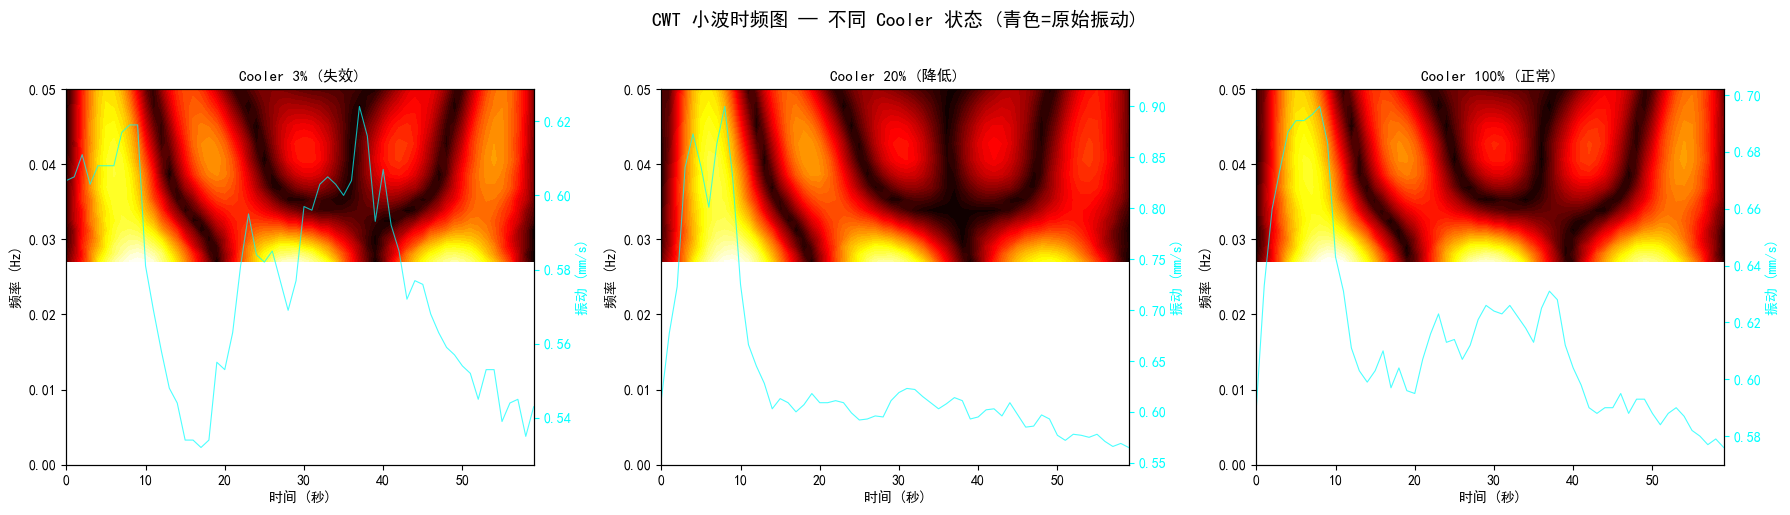

CWT 观察: 横轴=时间, 纵轴=频率, 关注 <0.05Hz 超低频的时频分布差异


In [9]:
import pywt

scales = np.arange(1, 31)
wavelet = "morl"
fs = 1.0

cooler_labels = {3: "Cooler 3% (失效)", 20: "Cooler 20% (降低)", 100: "Cooler 100% (正常)"}

# 选代表周期: Cooler 三种状态各取第一个周期
representatives = {}
for val, label in cooler_labels.items():
    idx = profile[profile["Cooler"] == val].index[0]
    representatives[label] = vs1.iloc[idx].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, signal_vals) in zip(axes, representatives.items()):
    coef, freqs = pywt.cwt(signal_vals, scales, wavelet, sampling_period=1/fs)
    power = np.abs(coef)
    im = ax.contourf(range(60), freqs, power, levels=50, cmap="hot")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("时间 (秒)")
    ax.set_ylabel("频率 (Hz)")
    ax.set_ylim(0, 0.05)
    ax_twin = ax.twinx()
    ax_twin.plot(range(60), signal_vals, "cyan", linewidth=0.8, alpha=0.7)
    ax_twin.set_ylabel("振动 (mm/s)", color="cyan")
    ax_twin.tick_params(axis="y", colors="cyan")

plt.suptitle("CWT 小波时频图 — 不同 Cooler 状态 (青色=原始振动)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("CWT 观察: 横轴=时间, 纵轴=频率, 关注 <0.05Hz 超低频的时频分布差异")

## 5. 故障分类建模 — VS1 振动能诊断哪种故障？

In [10]:
# 对每个周期提取多维度特征
def extract_features(row):
    x = row.values
    features = {
        'mean':   np.mean(x),
        'std':    np.std(x),
        'max':    np.max(x),
        'min':    np.min(x),
        'range':  np.max(x) - np.min(x),
        'rms':    np.sqrt(np.mean(x**2)),
        'crest':  np.max(np.abs(x)) / np.sqrt(np.mean(x**2)) if np.sqrt(np.mean(x**2)) > 0 else 0,
        'skew':   sp_stats.skew(x),
        'kurt':   sp_stats.kurtosis(x),
        'median': np.median(x),
        'seg1_mean': np.mean(x[:20]),
        'seg2_mean': np.mean(x[20:40]),
        'seg3_mean': np.mean(x[40:60]),
        'seg1_std':  np.std(x[:20]),
        'seg2_std':  np.std(x[20:40]),
        'seg3_std':  np.std(x[40:60]),
    }
    return pd.Series(features)

X = vs1.apply(extract_features, axis=1)
print(f"特征矩阵: {X.shape[0]} 周期 × {X.shape[1]} 特征")
print(f"\n特征列表: {list(X.columns)}")
X.head()


特征矩阵: 2205 周期 × 16 特征

特征列表: ['mean', 'std', 'max', 'min', 'range', 'rms', 'crest', 'skew', 'kurt', 'median', 'seg1_mean', 'seg2_mean', 'seg3_mean', 'seg1_std', 'seg2_std', 'seg3_std']


,mean,std,max,min,range,rms,crest,skew,kurt,median,seg1_mean,seg2_mean,seg3_mean,seg1_std,seg2_std,seg3_std
0,0.576950,0.026852,0.624,0.532,0.092,0.577575,1.080380,-0.044978,-1.275101,0.5770,0.57955,0.59035,0.56095,0.032904,0.017162,0.018535
1,0.565850,0.027013,0.626,0.524,0.102,0.566494,1.105042,0.770789,-0.238839,0.5595,0.57900,0.56755,0.55100,0.038837,0.009724,0.013780
2,0.576533,0.036422,0.662,0.529,0.133,0.577683,1.145958,0.934103,-0.042351,0.5620,0.59890,0.58065,0.55005,0.048506,0.017831,0.009505
3,0.569267,0.033184,0.645,0.527,0.118,0.570233,1.131117,1.007775,-0.165555,0.5550,0.58445,0.57410,0.54925,0.044302,0.025647,0.005337
4,0.577367,0.033203,0.660,0.524,0.136,0.578321,1.141235,0.795914,0.027945,0.5760,0.59230,0.58275,0.55705,0.046448,0.014394,0.016675


In [11]:
# 对四个故障标签分别用随机森林做多分类
target_config = {
    "Cooler":       [3, 20, 100],
    "Valve":        [73, 80, 90, 100],
    "Pump_Leakage": [0, 1, 2],
    "Accumulator":  [90, 100, 115, 130],
}

results = {}
for name, classes in target_config.items():
    valid_mask = profile[name].isin(classes)
    X_sub = X[valid_mask]
    y_raw = profile[name].values[valid_mask]

    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_sub, y_enc, cv=5, scoring='f1_weighted')

    rf.fit(X_sub, y_enc)
    importances = rf.feature_importances_
    top_idx = np.argsort(importances)[-5:][::-1]

    results[name] = {
        'f1_mean': scores.mean(),
        'f1_std':  scores.std(),
        'top_features': list(zip(X.columns[top_idx], importances[top_idx]))
    }
    print(f"{name:<14} → 5折CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

print("\nVS1 振动对各故障的分类能力:")
for name in ["Cooler", "Valve", "Pump_Leakage", "Accumulator"]:
    bar = "█" * int(results[name]['f1_mean'] * 40)
    print(f"  {name:<14}: {results[name]['f1_mean']:.3f}  {bar}")


Cooler         → 5折CV F1 = 0.9559 ± 0.0517


Valve          → 5折CV F1 = 0.3500 ± 0.0489


Pump_Leakage   → 5折CV F1 = 0.5932 ± 0.1368


Accumulator    → 5折CV F1 = 0.4189 ± 0.0954

VS1 振动对各故障的分类能力:
  Cooler        : 0.956  ██████████████████████████████████████
  Valve         : 0.350  ██████████████
  Pump_Leakage  : 0.593  ███████████████████████
  Accumulator   : 0.419  ████████████████


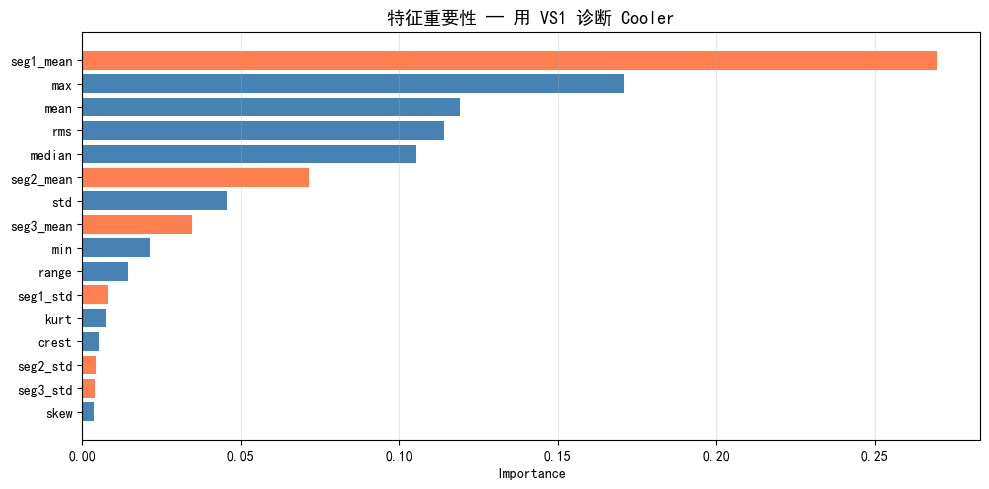

In [12]:
# 画最佳分类目标的特征重要性
best_name = max(results, key=lambda k: results[k]['f1_mean'])
valid_mask = profile[best_name].isin(target_config[best_name])
X_best = X[valid_mask]
y_best = profile[best_name].values[valid_mask]
le = LabelEncoder()
y_enc = le.fit_transform(y_best)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_best, y_enc)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if 'seg' not in f else 'coral' for f in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=[c for c in colors[::-1]])
ax.set_title(f"特征重要性 — 用 VS1 诊断 {best_name}", fontsize=13)
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


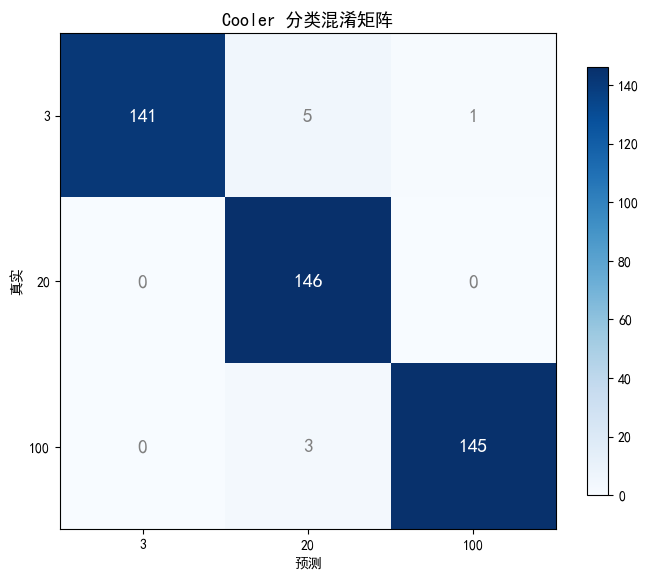

              precision    recall  f1-score   support

           3       1.00      0.96      0.98       147
          20       0.95      1.00      0.97       146
         100       0.99      0.98      0.99       148

    accuracy                           0.98       441
   macro avg       0.98      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441



In [13]:
# 混淆矩阵
X_train, X_test, y_train, y_test = train_test_split(X_best, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)
y_pred = rf2.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max()/2 else "gray")
ax.set_xticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(le.classes_)
ax.set_xlabel("预测")
ax.set_ylabel("真实")
ax.set_title(f"{best_name} 分类混淆矩阵", fontsize=13)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


## 6. 循环内阶段分割 — 60 秒液压循环分为哪几段？

检测到阶段边界点 (秒): [np.int64(17), np.int64(35)]


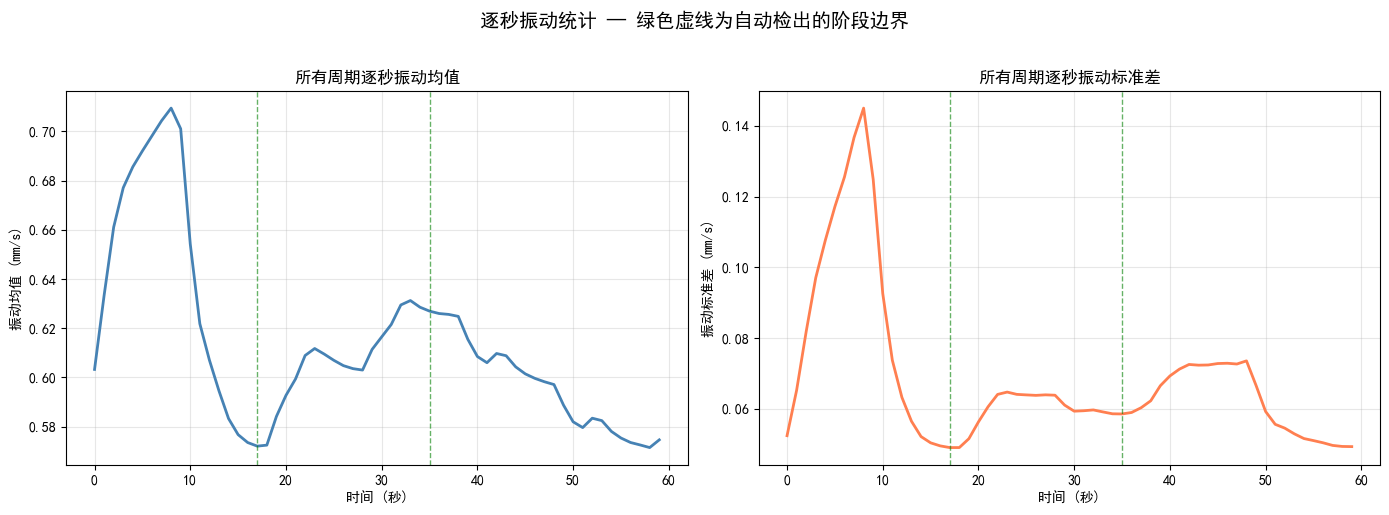

In [14]:
# 逐秒标准差 — 方差变化暗示循环阶段边界
second_std = vs1.std(axis=0)
second_mean = vs1.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(np.arange(0, 60), second_mean, linewidth=2, color="steelblue")
ax1.set_title("所有周期逐秒振动均值")
ax1.set_xlabel("时间 (秒)")
ax1.set_ylabel("振动均值 (mm/s)")
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(0, 60), second_std, linewidth=2, color="coral")
ax2.set_title("所有周期逐秒振动标准差")
ax2.set_xlabel("时间 (秒)")
ax2.set_ylabel("振动标准差 (mm/s)")
ax2.grid(True, alpha=0.3)

# 找 std 的局部极小值作为阶段边界
peaks_neg, _ = signal.find_peaks(-second_std.values, distance=5, prominence=0.001)
for ax in [ax1, ax2]:
    for p in peaks_neg:
        ax.axvline(x=p, color='green', linestyle='--', alpha=0.6, linewidth=1)
if len(peaks_neg) > 0:
    print(f"检测到阶段边界点 (秒): {list(peaks_neg)}")
plt.suptitle("逐秒振动统计 — 绿色虚线为自动检出的阶段边界", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


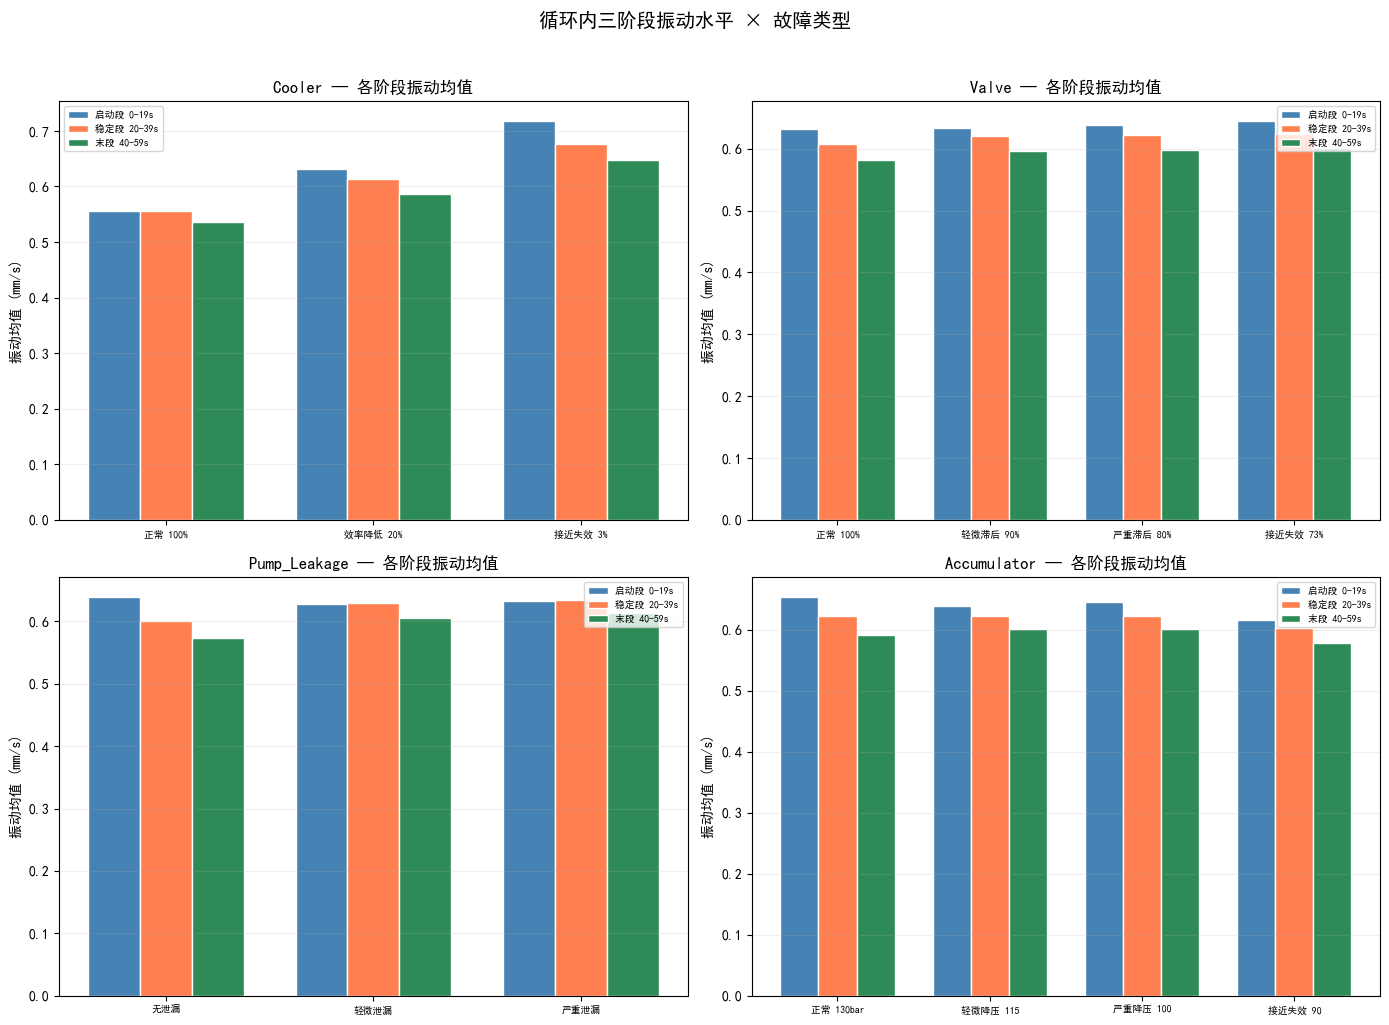

In [15]:
# 按三分段对比不同故障在各阶段的振动水平
segments = [(0, 20, "启动段 0-19s"), (20, 40, "稳定段 20-39s"), (40, 60, "末段 40-59s")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, labels) in zip(axes.flat, fault_config):
    x_pos  = np.arange(len(labels))
    width  = 0.25
    colors = ['steelblue', 'coral', 'seagreen']
    for si, (start, end, seg_name) in enumerate(segments):
        means = []
        for val in labels:
            mask = profile[col] == val
            if mask.sum() > 0:
                seg_mean = vs1[mask].iloc[:, start:end].values.mean()
                means.append(seg_mean)
            else:
                means.append(0)
        ax.bar(x_pos + si*width, means, width, label=seg_name, color=colors[si], edgecolor='white')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([name for _, name in labels.items()], fontsize=7)
    ax.set_title(f"{col} — 各阶段振动均值")
    ax.set_ylabel("振动均值 (mm/s)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle("循环内三阶段振动水平 × 故障类型", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. 退化追踪 — 振动随周期数如何演变？

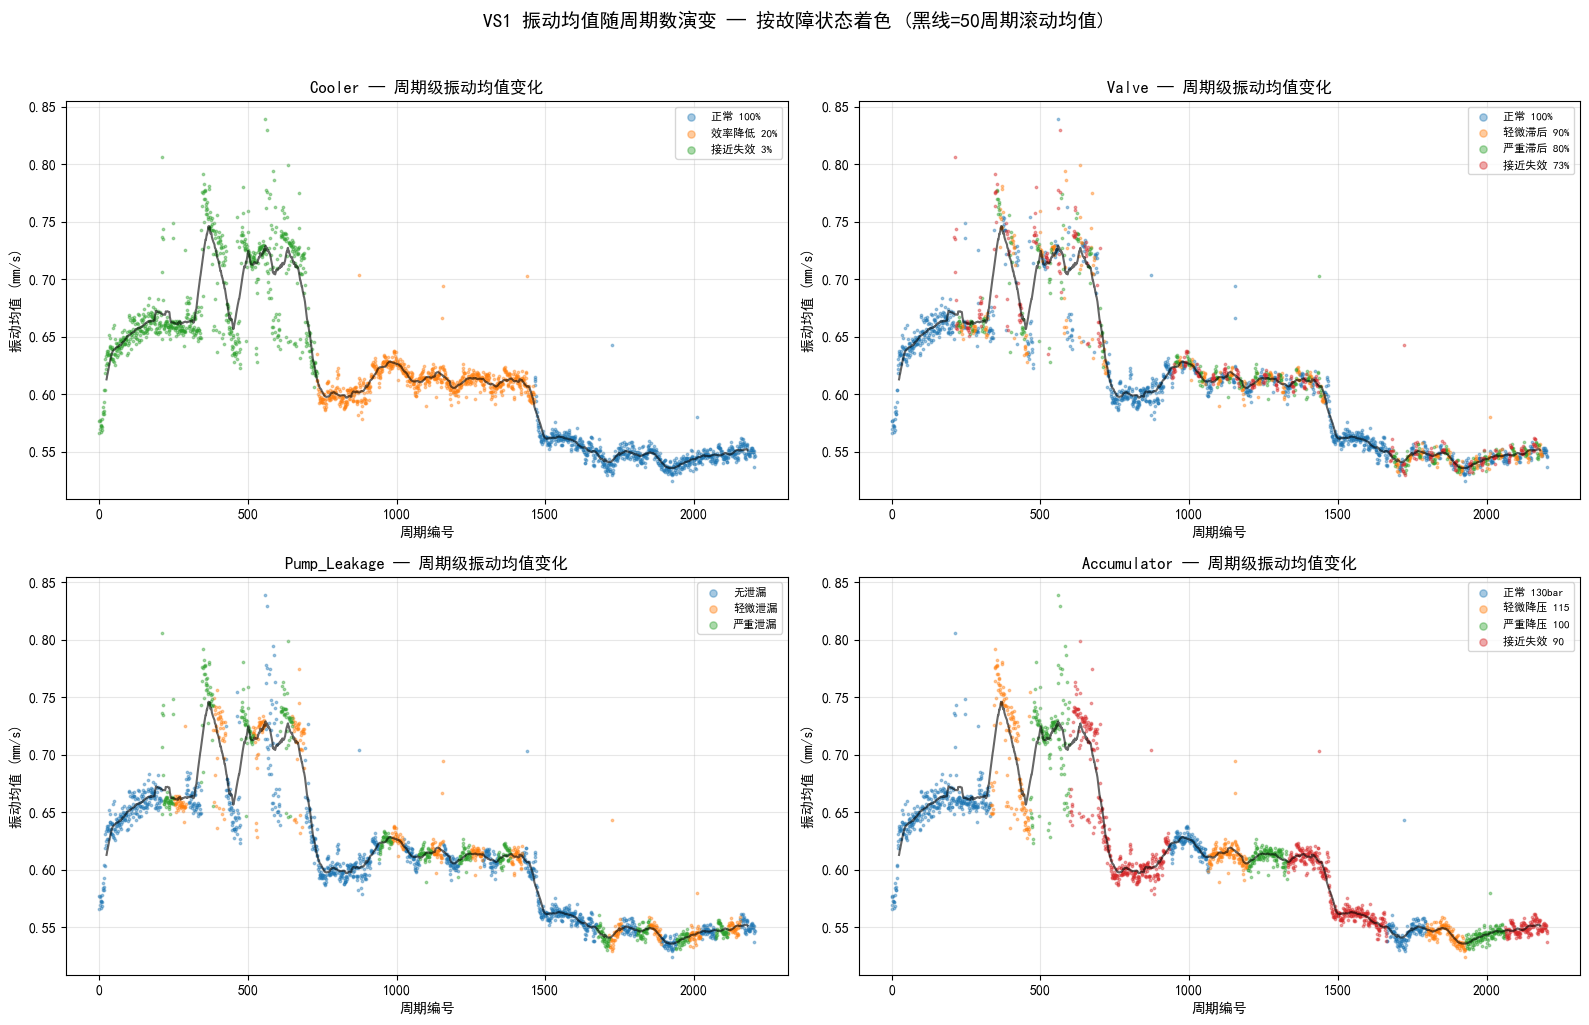

In [16]:
# 周期级振动均值 + 50 周期滚动平滑
vs1_stats['cycle_idx'] = np.arange(len(vs1_stats))
vs1_stats['rolling_mean'] = vs1_stats['mean'].rolling(window=50, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (col, labels) in zip(axes.flat, fault_config):
    for val, name in labels.items():
        mask = vs1_stats[col] == val
        if mask.sum() > 0:
            sub = vs1_stats[mask]
            ax.scatter(sub['cycle_idx'], sub['mean'], s=3, alpha=0.4, label=name)
    # 覆盖滚动均值
    ax.plot(vs1_stats['cycle_idx'], vs1_stats['rolling_mean'], color='black', linewidth=1.5, alpha=0.6)
    ax.set_xlabel("周期编号")
    ax.set_ylabel("振动均值 (mm/s)")
    ax.set_title(f"{col} — 周期级振动均值变化")
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(True, alpha=0.3)
plt.suptitle("VS1 振动均值随周期数演变 — 按故障状态着色 (黑线=50周期滚动均值)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 8. 形状聚类 (K-Shape)

不依赖故障标签，振动曲线自然分为几种模板形态？与 Cooler 标签吻合度如何？

Running K-Shape on 2205 vibration cycles...


K-Shape (3簇) vs Cooler 标签: ARI = 0.0000

列归一化交叉表 (每个Cooler状态分配到各簇的比例):
Cooler   3    20   100
Cluster               
0        1.0  1.0  1.0


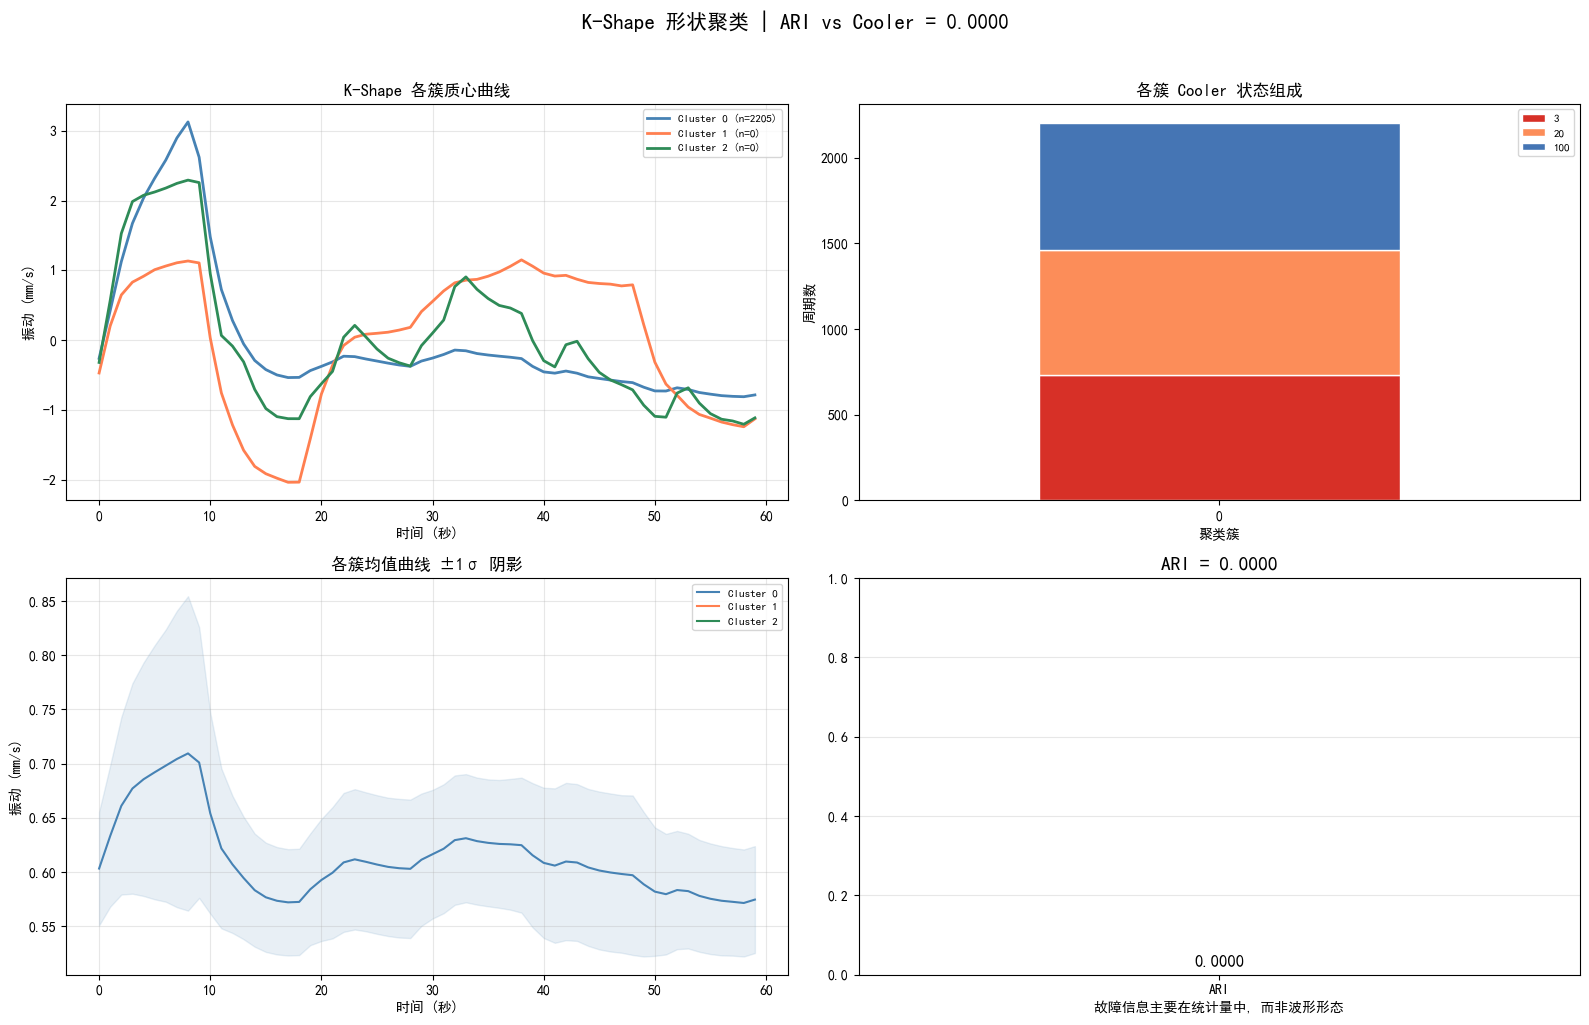


结论: 故障信息主要在统计量中, 而非波形形态


In [17]:
from tslearn.clustering import KShape
from sklearn.metrics import adjusted_rand_score

series_all = vs1.values.astype(np.float64)
cooler_true = profile["Cooler"].values

# K-Shape 聚类 (3簇对应3种Cooler状态)
print("Running K-Shape on 2205 vibration cycles...")
ks = KShape(n_clusters=3, random_state=42, n_init=3, max_iter=50, verbose=False)
cluster_labels = ks.fit_predict(series_all)

ari = adjusted_rand_score(cooler_true, cluster_labels)
print(f"K-Shape (3簇) vs Cooler 标签: ARI = {ari:.4f}")

# 交叉表
ct = pd.crosstab(
    pd.Series(cluster_labels, name="Cluster"),
    pd.Series(cooler_true, name="Cooler"),
    normalize="columns"
)
print("\n列归一化交叉表 (每个Cooler状态分配到各簇的比例):")
print(ct.round(3))

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
time = np.arange(60)
colors = ["steelblue", "coral", "seagreen"]

# 子图1: 质心曲线
for k in range(3):
    axes[0, 0].plot(time, ks.cluster_centers_[k], color=colors[k], linewidth=2,
        label=f"Cluster {k} (n={(cluster_labels==k).sum()})")
axes[0, 0].set_title("K-Shape 各簇质心曲线", fontsize=12)
axes[0, 0].set_xlabel("时间 (秒)")
axes[0, 0].set_ylabel("振动 (mm/s)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 子图2: 各簇Cooler状态组成
ct_count = pd.crosstab(pd.Series(cluster_labels, name="Cluster"),
    pd.Series(cooler_true, name="Cooler"))
ct_count.plot(kind="bar", stacked=True, ax=axes[0, 1],
    color=["#d73027", "#fc8d59", "#4575b4"], edgecolor="white")
axes[0, 1].set_title("各簇 Cooler 状态组成", fontsize=12)
axes[0, 1].set_xlabel("聚类簇")
axes[0, 1].set_ylabel("周期数")
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# 子图3: 均值±1SD
for k in range(3):
    cdata = series_all[cluster_labels == k]
    mean_c = cdata.mean(axis=0)
    std_c  = cdata.std(axis=0)
    axes[1, 0].plot(time, mean_c, color=colors[k], linewidth=1.5, label=f"Cluster {k}")
    axes[1, 0].fill_between(time, mean_c-std_c, mean_c+std_c, color=colors[k], alpha=0.12)
axes[1, 0].set_title("各簇均值曲线 ±1σ 阴影", fontsize=12)
axes[1, 0].set_xlabel("时间 (秒)")
axes[1, 0].set_ylabel("振动 (mm/s)")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 子图4: ARI bar + 结论
axes[1, 1].bar(["ARI"], [ari], color="steelblue", edgecolor="white", width=0.3)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title(f"ARI = {ari:.4f}", fontsize=14)
axes[1, 1].grid(True, alpha=0.3, axis="y")
axes[1, 1].text(0, ari + 0.02, f"{ari:.4f}", ha="center", fontsize=12, fontweight="bold")
if ari > 0.6:
    conclusion = "振动波形形态是 Cooler 故障的天然指纹"
elif ari > 0.3:
    conclusion = "波形形态部分反映故障, 统计量/频域特征可能更重要"
else:
    conclusion = "故障信息主要在统计量中, 而非波形形态"
axes[1, 1].set_xlabel(conclusion, fontsize=10)

plt.suptitle(f"K-Shape 形状聚类 | ARI vs Cooler = {ari:.4f}", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n结论: {conclusion}")

Cooler 状态切换次数: 2 次 (共 2205 周期)


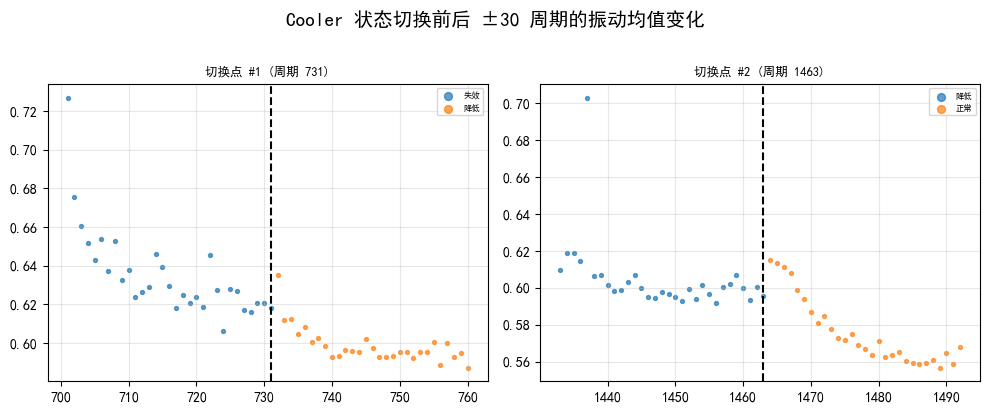

In [18]:
# Cooler 状态切换点前后 ±30 周期的振动变化
cooler_vals = profile["Cooler"].values
switch_points = np.where(np.diff(cooler_vals) != 0)[0]
print(f"Cooler 状态切换次数: {len(switch_points)} 次 (共 {len(vs1)} 周期)")

n_show = min(len(switch_points), 8)
if n_show == 0:
    print("没有检测到 Cooler 状态切换点，跳过此图")
else:
    cols = min(4, n_show)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    # 确保 axes 可以展平
    if n_show == 1:
        axes = [axes]
    else:
        axes = axes.flat
    for i in range(n_show):
        sp = switch_points[i]
        start = max(0, sp - 30)
        end   = min(len(vs1), sp + 30)
        local_cycles = vs1_stats.iloc[start:end]
        for val, name in [(3, "失效"), (20, "降低"), (100, "正常")]:
            mask_local = local_cycles["Cooler"] == val
            if mask_local.sum() > 0:
                sub = local_cycles[mask_local]
                axes[i].scatter(sub['cycle_idx'], sub['mean'], s=8, alpha=0.7, label=name)
        axes[i].axvline(x=sp, color='black', linestyle='--', linewidth=1.5)
        axes[i].set_title(f"切换点 #{i+1} (周期 {sp})", fontsize=9)
        axes[i].legend(fontsize=6, markerscale=2)
        axes[i].grid(True, alpha=0.3)
    # 隐藏多余的子图
    for j in range(n_show, rows * cols):
        if hasattr(axes, 'flat'):
            axes.flat[j].set_visible(False)
    plt.suptitle("Cooler 状态切换前后 ±30 周期的振动均值变化", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()